<a href="https://colab.research.google.com/github/hafsaaslam1212-star/UrbanMobility-DataAnalytics/blob/main/Big_Data_Analytics_using_Apache_Spark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
import os

BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"
print(os.listdir(BASE))

['complaints.csv', 'deliveries.csv', 'orders.csv', 'data_dictionary.csv', 'app_events.csv', 'drivers.csv', 'hubs.csv', 'README.txt', 'vehicles.csv', 'customers.csv', 'incidents.csv']


In [10]:
BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"

df = spark.read.csv(
    BASE + "deliveries.csv",
    header=True,
    inferSchema=True
)

In [16]:
import os

BASE = "/content/drive/MyDrive/northstar_data/northstar_dataset/"
print(os.listdir(BASE))

['complaints.csv', 'deliveries.csv', 'orders.csv', 'data_dictionary.csv', 'app_events.csv', 'drivers.csv', 'hubs.csv', 'README.txt', 'vehicles.csv', 'customers.csv', 'incidents.csv']


In [21]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NorthStar Analytics") \
    .getOrCreate()

df = spark.read.csv(
    "/content/drive/MyDrive/northstar_data/northstar_dataset/deliveries.csv",
    header=True,
    inferSchema=True
)

df.show(5)

+-----------+--------+---------+----------+------+-------------------+---------------------+---------------+-----------------+---------------------------+---------------------------+-----------------------------+-------------------+
|delivery_id|order_id|driver_id|vehicle_id|hub_id|      dispatch_time|delivery_completed_at|delivery_status|route_distance_km|manual_route_override_count|proof_of_completion_missing|customer_rating_post_delivery|fuel_or_charge_cost|
+-----------+--------+---------+----------+------+-------------------+---------------------+---------------+-----------------+---------------------------+---------------------------+-----------------------------+-------------------+
|    DL00001|  O00938|     D004|      V056|   H05|2024-06-18 10:57:00| 2024-06-19 09:05:...|         Failed|            17.26|                          1|                          0|                         3.07|              12.05|
|    DL00002|  O00004|     D138|      V007|   H02|2025-01-11 18:45:0

In [24]:
pandas_df = df.limit(5).toPandas()

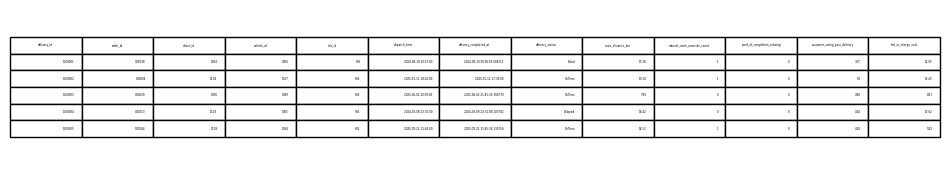

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2))
ax.axis('off')
ax.table(cellText=pandas_df.values,
         colLabels=pandas_df.columns,
         loc='center')
plt.savefig("delivery_table.png", dpi=300, bbox_inches='tight')